# Market Insights & Sales Analytics

## Python Exploratory Data Analysis

**Author:** Temitayo Medubi

This notebook analyzes the Sample Superstore dataset using Python, pandas and matplotlib.

The objectives are to:

- Validate the dataset
- Explore sales and profitability
- Examine regional and customer-segment performance
- Identify high-performing and loss-making products
- Evaluate the relationship between discounts and profit
- Generate business insights and recommendations

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load Dataset

file_path = "../Dataset/Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 9,994
Columns: 21


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
average_order_value = total_sales / total_orders
total_quantity = df["Quantity"].sum()
average_discount = df["Discount"].mean() * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Discount: {average_discount:.2f}%")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Orders: 5,009
Total Customers: 793
Average Order Value: $458.61
Total Quantity Sold: 37,873
Average Discount: 15.62%


In [9]:
# Convert date columns

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date conversion completed.")

Date conversion completed.


In [10]:
# Create time dimensions

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,October


In [11]:
sales_by_year = (
    df.groupby("Order Year")["Sales"]
      .sum()
      .reset_index()
)

sales_by_year

,Order Year,Sales
0,2014,"484,247.50"
1,2015,"470,532.51"
2,2016,"609,205.60"
3,2017,"733,215.26"


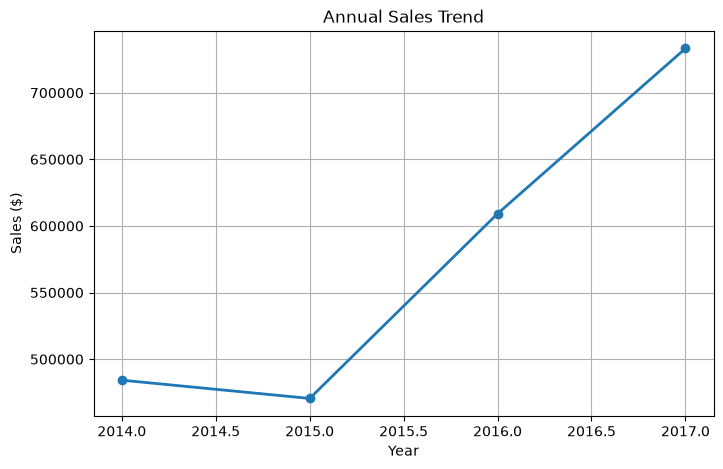

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    sales_by_year["Order Year"],
    sales_by_year["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Annual Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(True)

plt.savefig(
    "Charts/annual_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

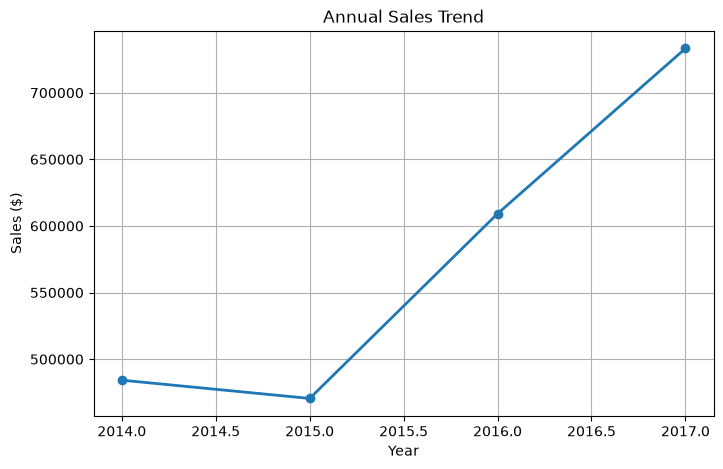

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    sales_by_year["Order Year"],
    sales_by_year["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Annual Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(True)

plt.savefig(
    "./Charts/annual_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Question 2

## Which region generates the highest sales?

This analysis evaluates revenue generated across all regions to identify the strongest-performing geographical markets.

In [16]:
sales_by_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_region

Region
West      725,457.82
East      678,781.24
Central   501,239.89
South     391,721.91
Name: Sales, dtype: float64

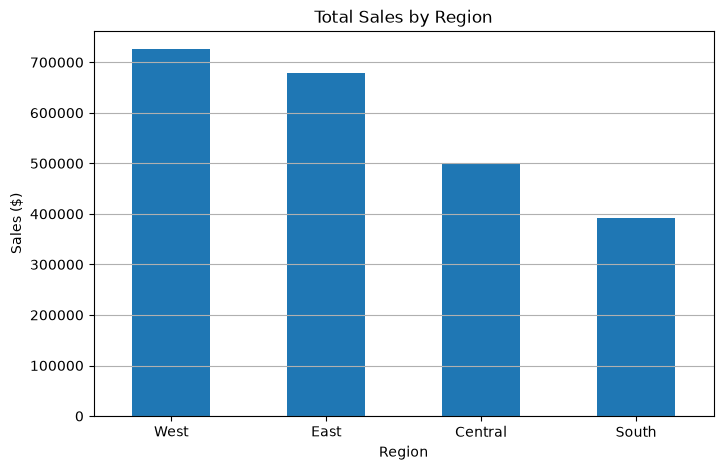

In [17]:
plt.figure(figsize=(8,5))

sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.grid(axis="y")

plt.savefig(
    "./Charts/sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

The West region generated the highest sales revenue among all regions.

The Central and East regions also performed strongly, while the South generated the lowest revenue.

## Recommendation

Management should continue investing in the West region while investigating opportunities to increase market penetration in the South through targeted marketing campaigns and product expansion.

# Business Question 2

## Which region generates the highest sales revenue?

This analysis evaluates revenue generated across all regions to identify the strongest-performing geographical markets and where management should focus future investments.

In [20]:
sales_by_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_region

Region
West      725,457.82
East      678,781.24
Central   501,239.89
South     391,721.91
Name: Sales, dtype: float64

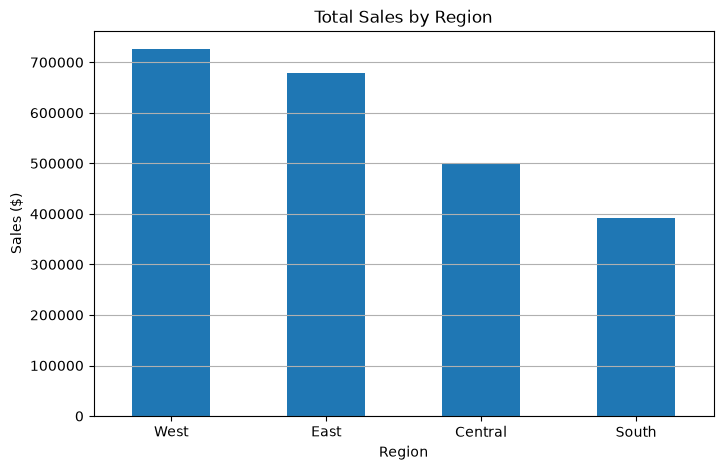

In [21]:
plt.figure(figsize=(8,5))

sales_by_region.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.grid(axis="y")

plt.savefig(
    "./Charts/sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

The West region generated the highest sales revenue, making it the strongest-performing market.

The Central and East regions also contributed significantly to total revenue, while the South recorded the lowest sales.

## Recommendation

Management should continue investing in the West while identifying growth opportunities in the South through targeted promotions, improved customer acquisition strategies and localized marketing campaigns.

# Business Question 3

## Which product category generates the highest revenue?

Understanding category performance helps management allocate inventory, marketing budgets and product development resources more effectively.

In [24]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology        836,154.03
Furniture         741,999.80
Office Supplies   719,047.03
Name: Sales, dtype: float64

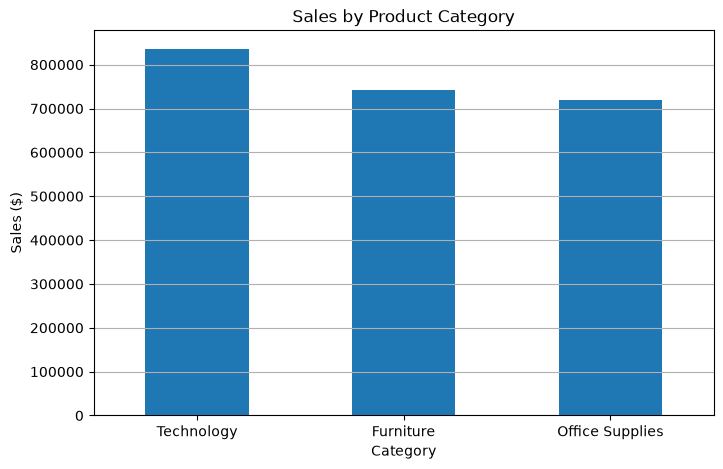

In [25]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.grid(axis="y")

plt.savefig(
    "./Charts/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

Technology generated the highest sales revenue, followed by Furniture and Office Supplies.

Technology products remain the company's strongest revenue driver.

## Recommendation

Management should prioritize inventory availability and marketing investments for Technology products while identifying opportunities to improve sales within lower-performing categories.

# Business Question 4

## Which product sub-categories generate the highest profit?

While revenue measures sales performance, profitability determines long-term business sustainability.

In [26]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_profit.head(10)

Sub-Category
Copiers       55,617.82
Phones        44,515.73
Accessories   41,936.64
Paper         34,053.57
Binders       30,221.76
Chairs        26,590.17
Storage       21,278.83
Appliances    18,138.01
Furnishings   13,059.14
Envelopes      6,964.18
Name: Profit, dtype: float64

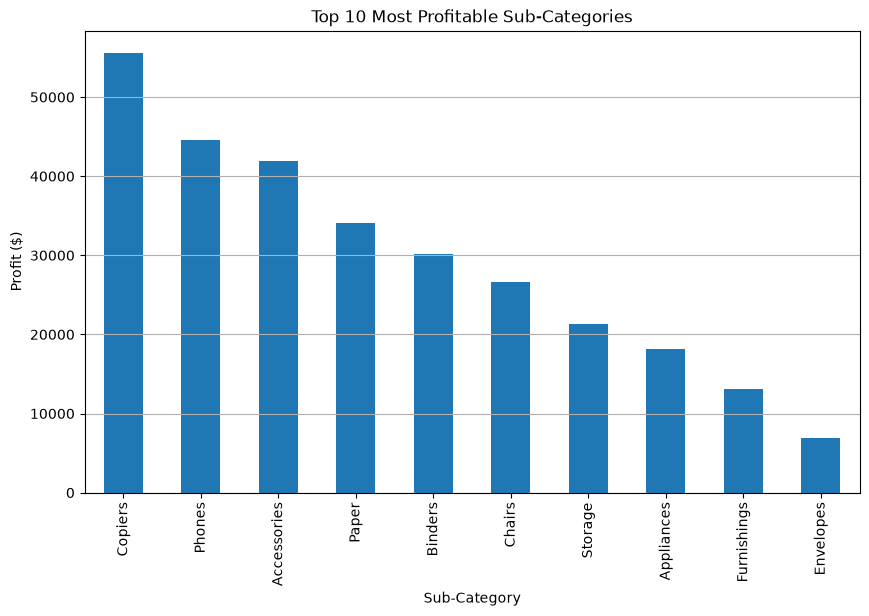

In [27]:
plt.figure(figsize=(10,6))

subcategory_profit.head(10).plot(kind="bar")

plt.title("Top 10 Most Profitable Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Profit ($)")

plt.grid(axis="y")

plt.savefig(
    "./Charts/top_profit_subcategories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

A small number of sub-categories generate a disproportionately large share of total profit.

These products should be regarded as strategic assets due to their strong contribution to business profitability.

## Recommendation

Increase inventory availability, supplier partnerships and marketing support for the highest-profit sub-categories while reviewing pricing strategies for less profitable products.

# Business Question 5

## Who are the company's highest-value customers?

Customer value is assessed based on total sales generated. Identifying top customers helps management strengthen customer relationships, improve retention, and prioritize high-value accounts.

In [30]:
top_customers = (
    df.groupby(["Customer ID", "Customer Name"])["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_customers

,Customer ID,Customer Name,Sales
0,SM-20320,Sean Miller,"25,043.05"
1,TC-20980,Tamara Chand,"19,052.22"
2,RB-19360,Raymond Buch,"15,117.34"
3,TA-21385,Tom Ashbrook,"14,595.62"
4,AB-10105,Adrian Barton,"14,473.57"
5,KL-16645,Ken Lonsdale,"14,175.23"
6,SC-20095,Sanjit Chand,"14,142.33"
7,HL-15040,Hunter Lopez,"12,873.30"
8,SE-20110,Sanjit Engle,"12,209.44"
9,CC-12370,Christopher Conant,"12,129.07"


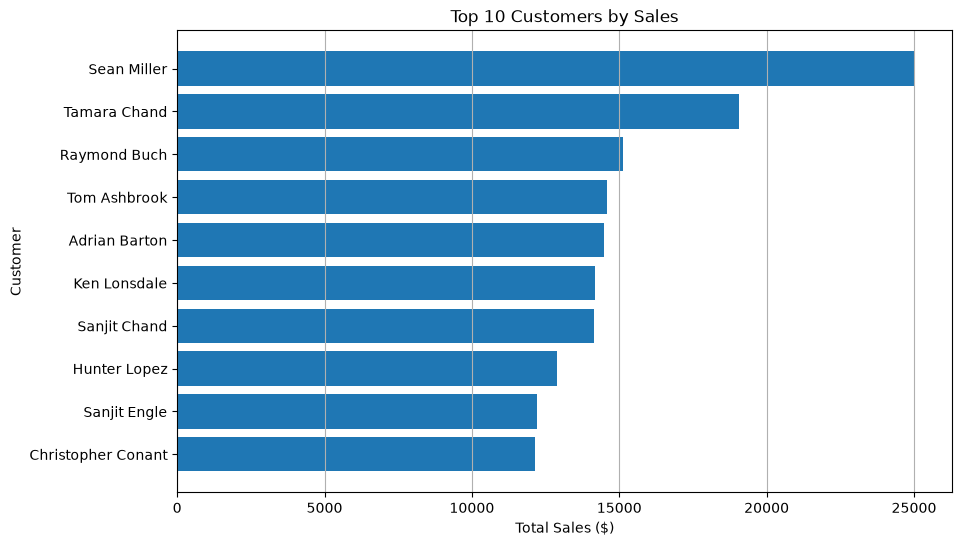

In [31]:
plt.figure(figsize=(10,6))

plt.barh(
    top_customers["Customer Name"],
    top_customers["Sales"]
)

plt.title("Top 10 Customers by Sales")

plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.savefig(
    "./Charts/top_customers_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

A relatively small group of customers contributes a significant portion of total revenue.

These customers represent strategic business assets whose continued loyalty directly influences company performance.

## Recommendation

Management should develop customer retention programs, personalized engagement strategies and premium support services for high-value customers to maximize lifetime value.

# Business Question 6

## Which customers generate the highest profit?

Revenue alone does not determine customer value. Profitability provides a clearer picture of long-term business contribution.

In [34]:
top_profit_customers = (
    df.groupby(["Customer ID", "Customer Name"])["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_profit_customers

,Customer ID,Customer Name,Profit
0,TC-20980,Tamara Chand,"8,981.32"
1,RB-19360,Raymond Buch,"6,976.10"
2,SC-20095,Sanjit Chand,"5,757.41"
3,HL-15040,Hunter Lopez,"5,622.43"
4,AB-10105,Adrian Barton,"5,444.81"
5,TA-21385,Tom Ashbrook,"4,703.79"
6,CM-12385,Christopher Martinez,"3,899.89"
7,KD-16495,Keith Dawkins,"3,038.63"
8,AR-10540,Andy Reiter,"2,884.62"
9,DR-12940,Daniel Raglin,"2,869.08"


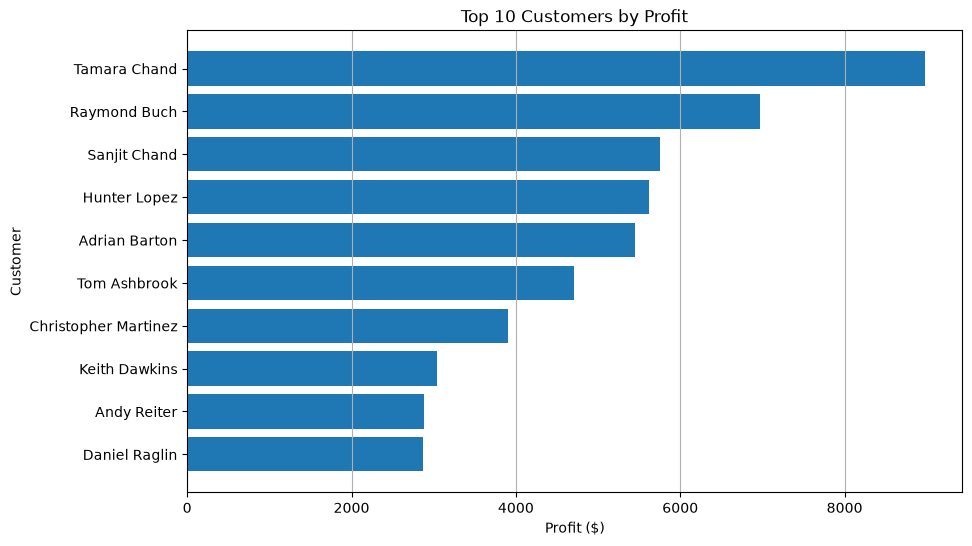

In [35]:
plt.figure(figsize=(10,6))

plt.barh(
    top_profit_customers["Customer Name"],
    top_profit_customers["Profit"]
)

plt.title("Top 10 Customers by Profit")

plt.xlabel("Profit ($)")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.savefig(
    "./Charts/top_profit_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

Some customers generate significantly higher profit than others, highlighting opportunities to strengthen relationships with the most valuable accounts.

## Recommendation

Management should identify the purchasing behaviors of high-profit customers and replicate successful sales strategies across similar customer segments.

# Business Question 7

## How does discount affect profitability?

One of the most important questions in retail analytics is whether higher discounts actually increase profitability or simply reduce margins.

This analysis explores the relationship between discounts offered and profit generated.

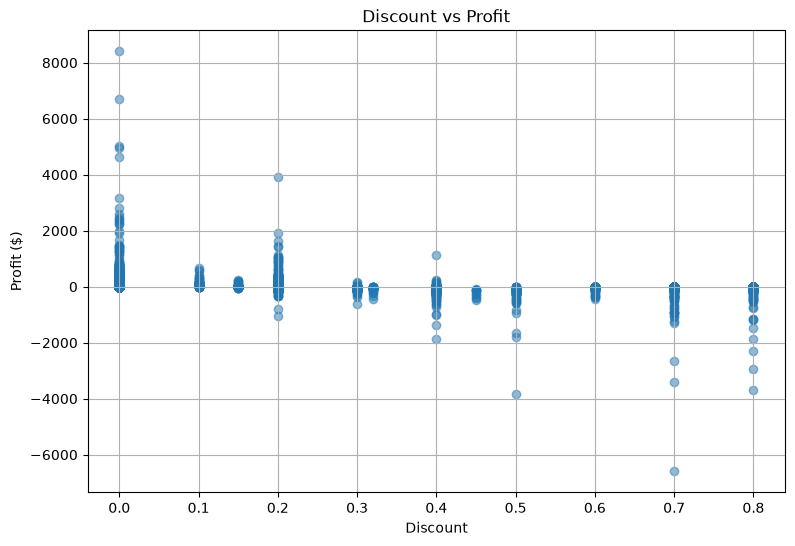

In [37]:
plt.figure(figsize=(9,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit ($)")

plt.grid(True)

plt.savefig(
    "./Charts/discount_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

The scatter plot indicates that higher discounts generally correspond with lower profits and, in many cases, negative profits.

Although discounts can stimulate sales volume, excessive discounting significantly reduces profitability.

## Recommendation

Management should establish optimal discount thresholds based on product category and customer segment to maximize both sales and profit.

# Business Question 8

## Which customer segment generates the highest sales?

Understanding customer segment performance enables management to target marketing resources more effectively.

In [40]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Consumer      1,161,401.34
Corporate       706,146.37
Home Office     429,653.15
Name: Sales, dtype: float64

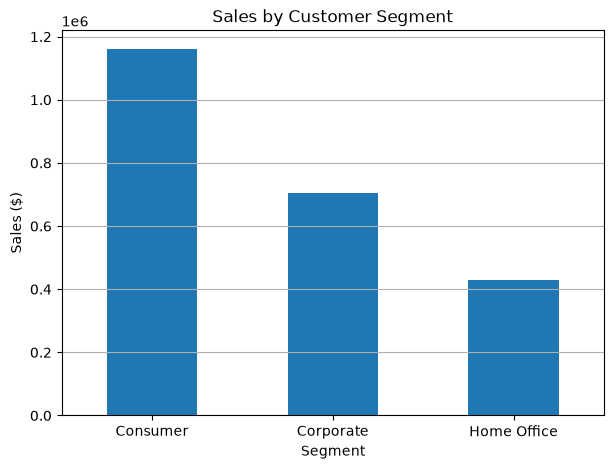

In [41]:
plt.figure(figsize=(7,5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")

plt.xlabel("Segment")

plt.ylabel("Sales ($)")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.savefig(
    "./Charts/sales_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

The Consumer segment contributes the largest proportion of total sales, followed by Corporate and Home Office customers.

## Recommendation

Management should continue investing in the Consumer segment while developing strategies to increase penetration within Corporate and Home Office markets.

# Business Question 9

## Which shipping mode is most frequently used?

Shipping performance directly affects customer satisfaction and logistics planning.

In [44]:
shipping = df["Ship Mode"].value_counts()

shipping

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

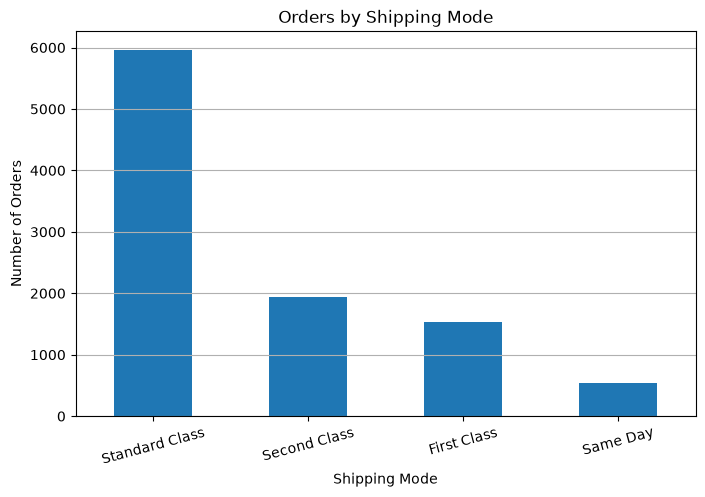

In [45]:
plt.figure(figsize=(8,5))

shipping.plot(kind="bar")

plt.title("Orders by Shipping Mode")

plt.xlabel("Shipping Mode")

plt.ylabel("Number of Orders")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.savefig(
    "./Charts/shipping_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

Standard Class is the most frequently used shipping method, indicating customer preference for cost-effective delivery options.

## Recommendation

Management should maintain high service levels for Standard Class while encouraging premium shipping options through targeted incentives.

# Business Question 10

## Is there a correlation between Sales, Profit and Discount?

Correlation analysis helps identify whether business variables move together and supports evidence-based decision-making.

In [48]:
correlation = df[["Sales","Profit","Discount"]].corr()

correlation

,Sales,Profit,Discount
Sales,1.00,0.48,-0.03
Profit,0.48,1.00,-0.22
Discount,-0.03,-0.22,1.00


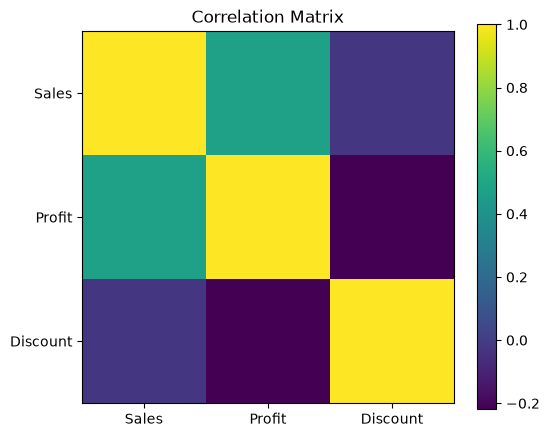

In [49]:
plt.figure(figsize=(6,5))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.savefig(
    "./Charts/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

Sales and Profit exhibit a positive relationship, while Discount generally shows a negative relationship with Profit.

The findings support the conclusion that excessive discounting negatively impacts profitability.

## Recommendation

Management should adopt data-driven pricing policies that balance revenue growth with sustainable profit margins.

# Final Executive Conclusion

This analysis demonstrates how Python can transform transactional sales data into actionable business intelligence.

Key findings include:

- Technology is the strongest-performing product category.
- The West region generates the highest revenue.
- A relatively small number of customers contribute disproportionately to total revenue.
- Higher discounts generally reduce profitability.
- Consumer customers remain the company's largest market segment.
- Standard Class dominates shipping preferences.

These insights provide management with evidence-based recommendations for improving pricing strategies, customer retention, inventory planning and regional sales performance.